### RAG Pipelines - Data Ingestion to Vector DB Pipeline

In [1]:
import os
from langchain_community.document_loaders import TextLoader,PyPDFLoader, PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from pathlib import Path

d:\RAG\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
### Read all the pdf's inside the directory
def process_all_pdfs(pdf_directory):
    """Process all PDF files in a directory"""
    all_documents = []
    pdf_dir = Path(pdf_directory)
    
    # Find all PDF files recursively
    pdf_files = list(pdf_dir.glob("**/*.pdf"))
    
    print(f"Found {len(pdf_files)} PDF files to process")
    
    for pdf_file in pdf_files:
        print(f"\nProcessing: {pdf_file.name}")
        try:
            loader = PyPDFLoader(str(pdf_file))
            documents = loader.load()
            
            # Add source information to metadata
            for doc in documents:
                doc.metadata['source_file'] = pdf_file.name
                doc.metadata['file_type'] = 'pdf'
            
            all_documents.extend(documents)
            print(f"  ✓ Loaded {len(documents)} pages")
            
        except Exception as e:
            print(f"  ✗ Error: {e}")
    
    print(f"\nTotal documents loaded: {len(all_documents)}")
    return all_documents

# Process all PDFs in the data directory
all_pdf_documents = process_all_pdfs("../data")

Found 5 PDF files to process

Processing: 1610.08229v1.pdf
  ✓ Loaded 16 pages

Processing: Anshita-Student-prompt.pdf
  ✓ Loaded 2 pages

Processing: attention-is-all-you-need.pdf
  ✓ Loaded 15 pages

Processing: full_chat_summary.pdf
  ✓ Loaded 2 pages

Processing: SustainabilityReport_Oct2020_FINAL.pdf
  ✓ Loaded 9 pages

Total documents loaded: 44


In [3]:
all_pdf_documents

[Document(metadata={'producer': 'pdfTeX-1.40.12', 'creator': 'LaTeX with hyperref package', 'creationdate': '2016-10-27T00:23:22+00:00', 'author': '', 'keywords': '', 'moddate': '2016-10-27T00:23:22+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.1415926-2.3-1.40.12 (TeX Live 2011) kpathsea version 6.0.1', 'subject': '', 'title': '', 'trapped': '/False', 'source': '..\\data\\pdf_files\\1610.08229v1.pdf', 'total_pages': 16, 'page': 0, 'page_label': '1', 'source_file': '1610.08229v1.pdf', 'file_type': 'pdf'}, page_content='Word Embeddings and Their Use In\nSentence Classiﬁcation Tasks\nAmit Mandelbaum Adi Shalev\nHebrew University of Jerusalm\namit.mandelbaum@mail.huji.ac.il bitan.adi@gmail.com\nOctober 27, 2016\nAbstract\nThis paper has two parts. In the ﬁrst part we discuss word embeddings. We discuss the need for them, some\nof the methods to create them, and some of their interesting properties. We also compare them to image\nembeddings and see how word embedding and image embe

### Chunking

In [4]:
### Text splitting get into chunks

def split_documents(documents,chunk_size=1000,chunk_overlap=200):
    """Split documents into smaller chunks for better RAG performance"""
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        length_function=len,
        separators=["\n\n", "\n", " ", ""]
    )
    split_docs = text_splitter.split_documents(documents)
    print(f"Split {len(documents)} documents into {len(split_docs)} chunks")
    
    # Show example of a chunk
    if split_docs:
        print(f"\nExample chunk:")
        print(f"Content: {split_docs[0].page_content[:200]}...")
        print(f"Metadata: {split_docs[0].metadata}")
    
    return split_docs

In [5]:
chunks=split_documents(all_pdf_documents)
chunks

Split 44 documents into 137 chunks

Example chunk:
Content: Word Embeddings and Their Use In
Sentence Classiﬁcation Tasks
Amit Mandelbaum Adi Shalev
Hebrew University of Jerusalm
amit.mandelbaum@mail.huji.ac.il bitan.adi@gmail.com
October 27, 2016
Abstract
Thi...
Metadata: {'producer': 'pdfTeX-1.40.12', 'creator': 'LaTeX with hyperref package', 'creationdate': '2016-10-27T00:23:22+00:00', 'author': '', 'keywords': '', 'moddate': '2016-10-27T00:23:22+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.1415926-2.3-1.40.12 (TeX Live 2011) kpathsea version 6.0.1', 'subject': '', 'title': '', 'trapped': '/False', 'source': '..\\data\\pdf_files\\1610.08229v1.pdf', 'total_pages': 16, 'page': 0, 'page_label': '1', 'source_file': '1610.08229v1.pdf', 'file_type': 'pdf'}


[Document(metadata={'producer': 'pdfTeX-1.40.12', 'creator': 'LaTeX with hyperref package', 'creationdate': '2016-10-27T00:23:22+00:00', 'author': '', 'keywords': '', 'moddate': '2016-10-27T00:23:22+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.1415926-2.3-1.40.12 (TeX Live 2011) kpathsea version 6.0.1', 'subject': '', 'title': '', 'trapped': '/False', 'source': '..\\data\\pdf_files\\1610.08229v1.pdf', 'total_pages': 16, 'page': 0, 'page_label': '1', 'source_file': '1610.08229v1.pdf', 'file_type': 'pdf'}, page_content='Word Embeddings and Their Use In\nSentence Classiﬁcation Tasks\nAmit Mandelbaum Adi Shalev\nHebrew University of Jerusalm\namit.mandelbaum@mail.huji.ac.il bitan.adi@gmail.com\nOctober 27, 2016\nAbstract\nThis paper has two parts. In the ﬁrst part we discuss word embeddings. We discuss the need for them, some\nof the methods to create them, and some of their interesting properties. We also compare them to image\nembeddings and see how word embedding and image embe

### embedding And vectorStoreDB

In [6]:
import os
import numpy as np
from sentence_transformers import SentenceTransformer
import chromadb
from chromadb.config import Settings
import uuid
from typing import List, Dict, Any, Tuple
from sklearn.metrics.pairwise import cosine_similarity

In [7]:
class EmbeddingManager:
    """Handles document embedding generation using SentenceTransformer"""
    
    def __init__(self, model_name: str = "all-MiniLM-L6-v2"):
        """
        Initialize the embedding manager
        
        Args:
            model_name: HuggingFace model name for sentence embeddings
        """
        self.model_name = model_name
        self.model = None
        self._load_model()

    def _load_model(self):
        """Load the SentenceTransformer model"""
        try:
            print(f"Loading embedding model: {self.model_name}")
            self.model = SentenceTransformer(self.model_name)
            print(f"Model loaded successfully. Embedding dimension: {self.model.get_embedding_dimension()}")
        except Exception as e:
            print(f"Error loading model {self.model_name}: {e}")
            raise

    def generate_embeddings(self, texts: List[str]) -> np.ndarray:
        """
        Generate embeddings for a list of texts
        
        Args:
            texts: List of text strings to embed
            
        Returns:
            numpy array of embeddings with shape (len(texts), embedding_dim)
        """
        if not self.model:
            raise ValueError("Model not loaded")
        
        print(f"Generating embeddings for {len(texts)} texts...")
        embeddings = self.model.encode(texts, show_progress_bar=True)
        print(f"Generated embeddings with shape: {embeddings.shape}")
        return embeddings


## initialize the embedding manager

embedding_manager=EmbeddingManager()
embedding_manager

Loading embedding model: all-MiniLM-L6-v2


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5917.42it/s]


Model loaded successfully. Embedding dimension: 384


### VectorStore

In [8]:
class VectorStore:
    """Manages document embeddings in a ChromaDB vector store"""
    
    def __init__(self, collection_name: str = "pdf_documents", persist_directory: str = "../data/vector_store"):
        """
        Initialize the vector store
        
        Args:
            collection_name: Name of the ChromaDB collection
            persist_directory: Directory to persist the vector store
        """
        self.collection_name = collection_name
        self.persist_directory = persist_directory
        self.client = None
        self.collection = None
        self._initialize_store()

    def _initialize_store(self):
        """Initialize ChromaDB client and collection"""
        try:
            # Create persistent ChromaDB client
            os.makedirs(self.persist_directory, exist_ok=True)
            self.client = chromadb.PersistentClient(path=self.persist_directory)
            
            # Get or create collection
            self.collection = self.client.get_or_create_collection(
                name=self.collection_name,
                metadata={"description": "PDF document embeddings for RAG"}
            )
            print(f"Vector store initialized. Collection: {self.collection_name}")
            print(f"Existing documents in collection: {self.collection.count()}")
            
        except Exception as e:
            print(f"Error initializing vector store: {e}")
            raise

    def add_documents(self, documents: List[Any], embeddings: np.ndarray):
        """
        Add documents and their embeddings to the vector store
        
        Args:
            documents: List of LangChain documents
            embeddings: Corresponding embeddings for the documents
        """
        if len(documents) != len(embeddings):
            raise ValueError("Number of documents must match number of embeddings")
        
        print(f"Adding {len(documents)} documents to vector store...")
        
        # Prepare data for ChromaDB
        ids = []
        metadatas = []
        documents_text = []
        embeddings_list = []
        
        for i, (doc, embedding) in enumerate(zip(documents, embeddings)):
            # Generate unique ID
            doc_id = f"doc_{uuid.uuid4().hex[:8]}_{i}"
            ids.append(doc_id)
            
            # Prepare metadata
            metadata = dict(doc.metadata)
            metadata['doc_index'] = i
            metadata['content_length'] = len(doc.page_content)
            metadatas.append(metadata)
            
            # Document content
            documents_text.append(doc.page_content)
            
            # Embedding
            embeddings_list.append(embedding.tolist())
        
        # Add to collection
        try:
            self.collection.add(
                ids=ids,
                embeddings=embeddings_list,
                metadatas=metadatas,
                documents=documents_text
            )
            print(f"Successfully added {len(documents)} documents to vector store")
            print(f"Total documents in collection: {self.collection.count()}")
            
        except Exception as e:
            print(f"Error adding documents to vector store: {e}")
            raise

vectorstore=VectorStore()
vectorstore

Vector store initialized. Collection: pdf_documents
Existing documents in collection: 567


In [9]:
chunks

[Document(metadata={'producer': 'pdfTeX-1.40.12', 'creator': 'LaTeX with hyperref package', 'creationdate': '2016-10-27T00:23:22+00:00', 'author': '', 'keywords': '', 'moddate': '2016-10-27T00:23:22+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.1415926-2.3-1.40.12 (TeX Live 2011) kpathsea version 6.0.1', 'subject': '', 'title': '', 'trapped': '/False', 'source': '..\\data\\pdf_files\\1610.08229v1.pdf', 'total_pages': 16, 'page': 0, 'page_label': '1', 'source_file': '1610.08229v1.pdf', 'file_type': 'pdf'}, page_content='Word Embeddings and Their Use In\nSentence Classiﬁcation Tasks\nAmit Mandelbaum Adi Shalev\nHebrew University of Jerusalm\namit.mandelbaum@mail.huji.ac.il bitan.adi@gmail.com\nOctober 27, 2016\nAbstract\nThis paper has two parts. In the ﬁrst part we discuss word embeddings. We discuss the need for them, some\nof the methods to create them, and some of their interesting properties. We also compare them to image\nembeddings and see how word embedding and image embe

Now from these chunks we'll generate the embedding

In [10]:
### Convert the text to embeddings
texts=[doc.page_content for doc in chunks]          # text from doc.page_content

## Generate the Embeddings

embeddings=embedding_manager.generate_embeddings(texts)  # we're calling function generate_embeddings() with the object embedding_manager

##store int he vector database
vectorstore.add_documents(chunks,embeddings)

Generating embeddings for 137 texts...


Batches: 100%|██████████| 5/5 [00:03<00:00,  1.46it/s]


Generated embeddings with shape: (137, 384)
Adding 137 documents to vector store...
Successfully added 137 documents to vector store
Total documents in collection: 704


Now you can see in the ../data there is a new folder with name vector_store and we have done the persistent over here. Persistent basically means now it is saved in this particular hard disk, we can load this hard disk and go ahead and execute anything as such.

We have completed this


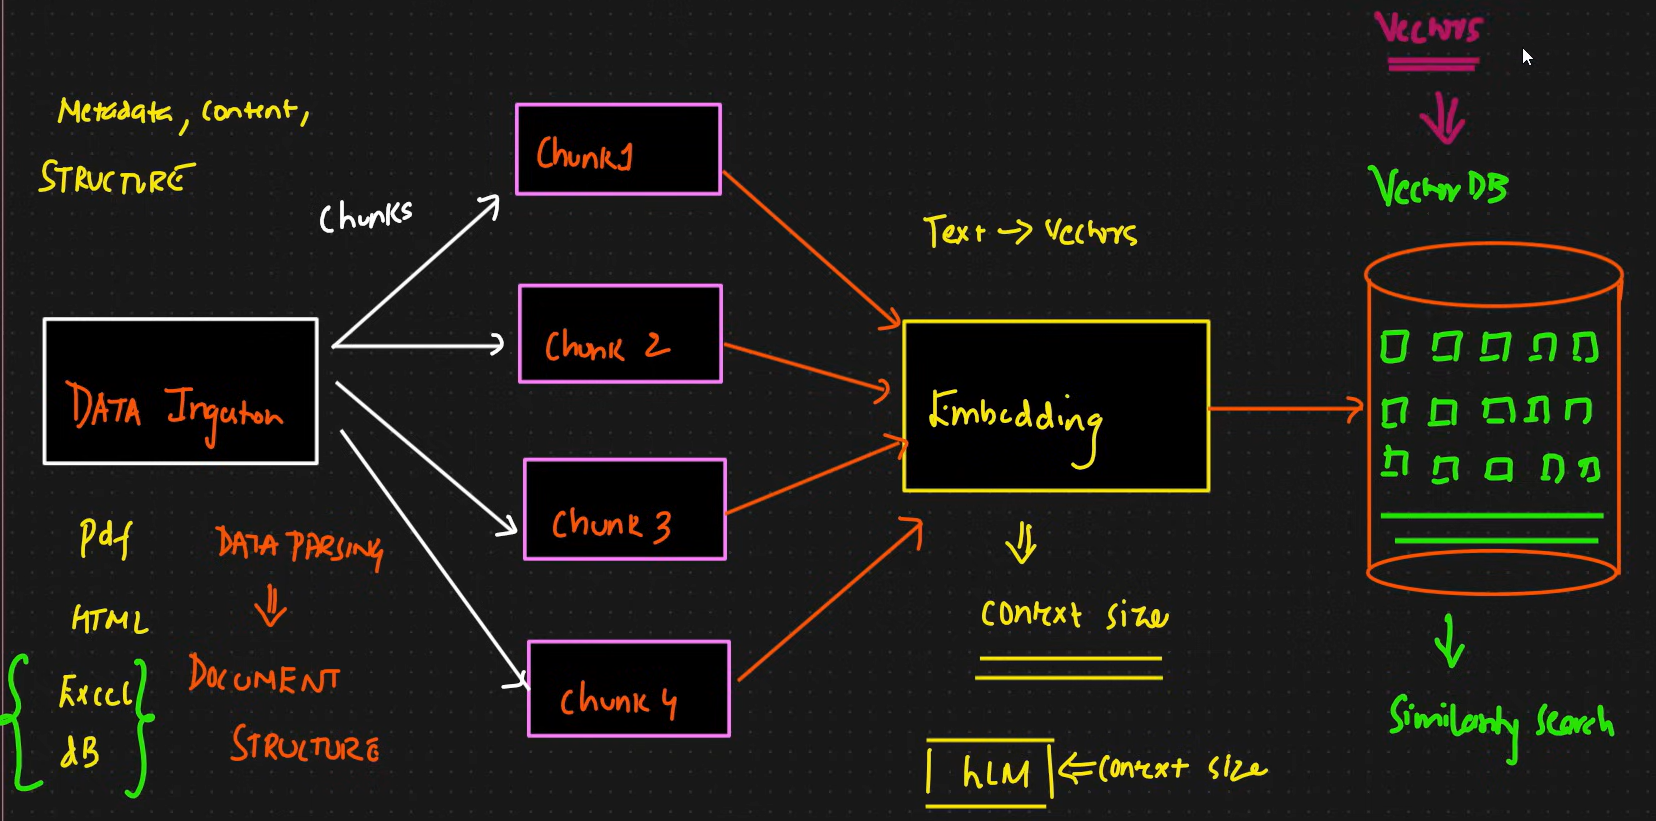

Now our question is how to perform retrieval?

Because in retrieval what happens is that whenever we have a user query we have to take that query and we have to convert that into embeddings again. 

Then we go ahead and hit the vector store in the form of a retriever and then only we get the context.

So in our example we'll try to get till , we have the user query , we convert that query into embeddings then we hit the vector store and get the context.

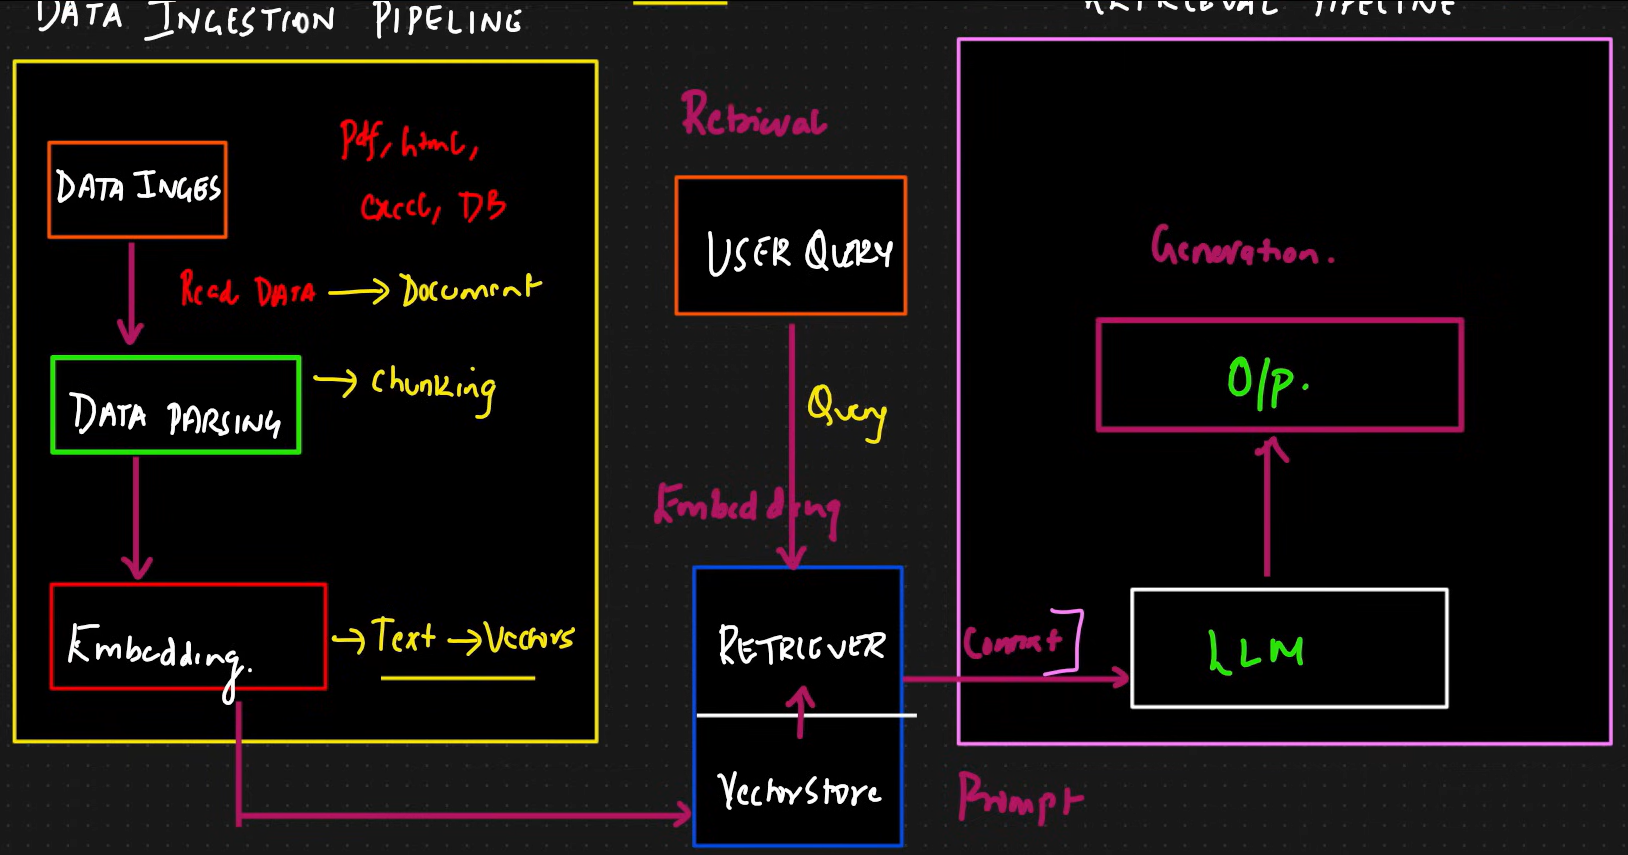

We'll go ahead create this pipeline now. We'll try to create a RAG retriever.

### Retriever Pipeline From VectorStore

In [11]:
class RAGRetriever:
    """Handles query-based retrieval from the vector store"""
    
    def __init__(self, vector_store: VectorStore, embedding_manager: EmbeddingManager):
        """
        Initialize the retriever
        
        Args:
            vector_store: Vector store containing document embeddings
            embedding_manager: Manager for generating query embeddings
        """
        self.vector_store = vector_store
        self.embedding_manager = embedding_manager

    def retrieve(self, query: str, top_k: int = 5, score_threshold: float = 0.0) -> List[Dict[str, Any]]:       # this retrieve function is really important because its main work is to retrieve based on a specific query  --> function will return the list of results

        ## top_k -->  how many top results we want
        """
        Retrieve relevant documents for a query
        
        Args:
            query: The search query
            top_k: Number of top results to return
            score_threshold: Minimum similarity score threshold
            
        Returns:
            List of dictionaries containing retrieved documents and metadata
        """
        print(f"Retrieving documents for query: '{query}'")
        print(f"Top K: {top_k}, Score threshold: {score_threshold}")
        
        # Generate query embedding
        query_embedding = self.embedding_manager.generate_embeddings([query])[0]        # generate_embeddings() defined in EmbeddingManager class   

        ## whenever we  get a query a query first needs to be converted into embedding so that we can do the similarity search in the retriever itself.
        
        # Search in vector store
        try:
            results = self.vector_store.collection.query(
                query_embeddings=[query_embedding.tolist()],
                n_results=top_k
            )           # we are giving query_embeddings in the form of a list
            

            ## once you get the results,in the results internally there will be a key which is called as documents. 

            # Process results
            retrieved_docs = []
            
            if results['documents'] and results['documents'][0]:
                documents = results['documents'][0]
                metadatas = results['metadatas'][0]
                distances = results['distances'][0]
                ids = results['ids'][0]
                
                for i, (doc_id, document, metadata, distance) in enumerate(zip(ids, documents, metadatas, distances)):
                    # Convert distance to similarity score (ChromaDB uses cosine distance)
                    similarity_score = 1 - distance         ## how similar those text data is basically coming up outside this vector store
                    
                    if similarity_score >= score_threshold:
                        retrieved_docs.append({
                            'id': doc_id,
                            'content': document,
                            'metadata': metadata,
                            'similarity_score': similarity_score,
                            'distance': distance,
                            'rank': i + 1
                        })
                
                print(f"Retrieved {len(retrieved_docs)} documents (after filtering)")
            else:
                print("No documents found")
            
            return retrieved_docs
            
        except Exception as e:
            print(f"Error during retrieval: {e}")
            return []

rag_retriever=RAGRetriever(vectorstore,embedding_manager)
rag_retriever

Whenever we create an retriever one thing we really need to understand this retriever is actually built on the top of the vector store and retriever is nothing but a simple interface based on whatever query we get. This retriever is just going to give you the response back. This retriever is basically a kind of interface which is connected to the vector store.

In [12]:
rag_retriever.retrieve("What is attention is all you need")

Retrieving documents for query: 'What is attention is all you need'
Top K: 5, Score threshold: 0.0
Generating embeddings for 1 texts...


Batches: 100%|██████████| 1/1 [00:00<00:00,  9.00it/s]

Generated embeddings with shape: (1, 384)
Retrieved 5 documents (after filtering)


[{'id': 'doc_855d9f81_16',
  'content': '3.2 Attention\nAn attention function can be described as mapping a query and a set of key-value pairs to an output,\nwhere the query, keys, values, and output are all vectors. The output is computed as a weighted sum\n3',
  'metadata': {'total_pages': 15,
   'subject': '',
   'page_label': '3',
   'source': '..\\data\\pdf_files\\attention-is-all-you-need.pdf',
   'source_file': 'attention-is-all-you-need.pdf',
   'moddate': '2024-04-10T21:11:43+00:00',
   'doc_index': 16,
   'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5',
   'creator': 'LaTeX with hyperref',
   'creationdate': '2024-04-10T21:11:43+00:00',
   'file_type': 'pdf',
   'page': 2,
   'trapped': '/False',
   'content_length': 216,
   'author': '',
   'title': '',
   'producer': 'pdfTeX-1.40.25',
   'keywords': ''},
  'similarity_score': 0.13995468616485596,
  'distance': 0.860045313835144,
  'rank': 1},
 {'id': 'doc_7998730a_

In [13]:
rag_retriever.retrieve("Career planning")

Retrieving documents for query: 'Career planning'
Top K: 5, Score threshold: 0.0
Generating embeddings for 1 texts...


Batches: 100%|██████████| 1/1 [00:00<00:00, 38.57it/s]

Generated embeddings with shape: (1, 384)
Retrieved 5 documents (after filtering)


[{'id': 'doc_42671b7e_57',
  'content': 'resume review like a hiring manager, testing ML understanding, and full mock interviews.\nBetter Questions for a Student Still Building Skills\n\x7f Questions were reframed honestly to reflect being strong in math/stats but still building depth in\nPython, SQL, ML, projects, and interviews.\n\x7f Focus areas included: what to master first, reasons recruiters may reject the profile, what projects\nto build, how to test real ML understanding, and how to prioritize competing preparation areas.\nAI + Career Strategy\n\x7f Preparation should consider rapid AI growth and changing hiring trends.\n\x7f High-value questions included: which roles will remain valuable in the next 3–5 years, which skills\nare replaceable by AI, whether to focus on ML Engineering, Analytics, GenAI, or business\nproblem-solving, and how a fresher should compete in an AI-first market.\nIndustry Perspective Prompt\n\x7f A strong prompt was framed to ask for honest recommendatio

Now the thing that's left is that you just need to integrate LLM with this specific context.

Now we're going to go towards the second pipeline that is the query retrieval pipeline wherein we are also going to use LLM with it. We'll use LLM models and these LLM models will help us to generate a summarized output in the RAG.

When we're taking about the query retrieval pipeline, we are specifically talking about something called as augmented generation.
Prompt is just like the instruction to the LLM, how LLM should basically work.

Context + Prompt step is called as augmentation wherein we are taking the context along with that we are also combining it with a specific prompt.

We'll generate the output from the LLM and this step is called generation.

So the entire pipeline will look like this

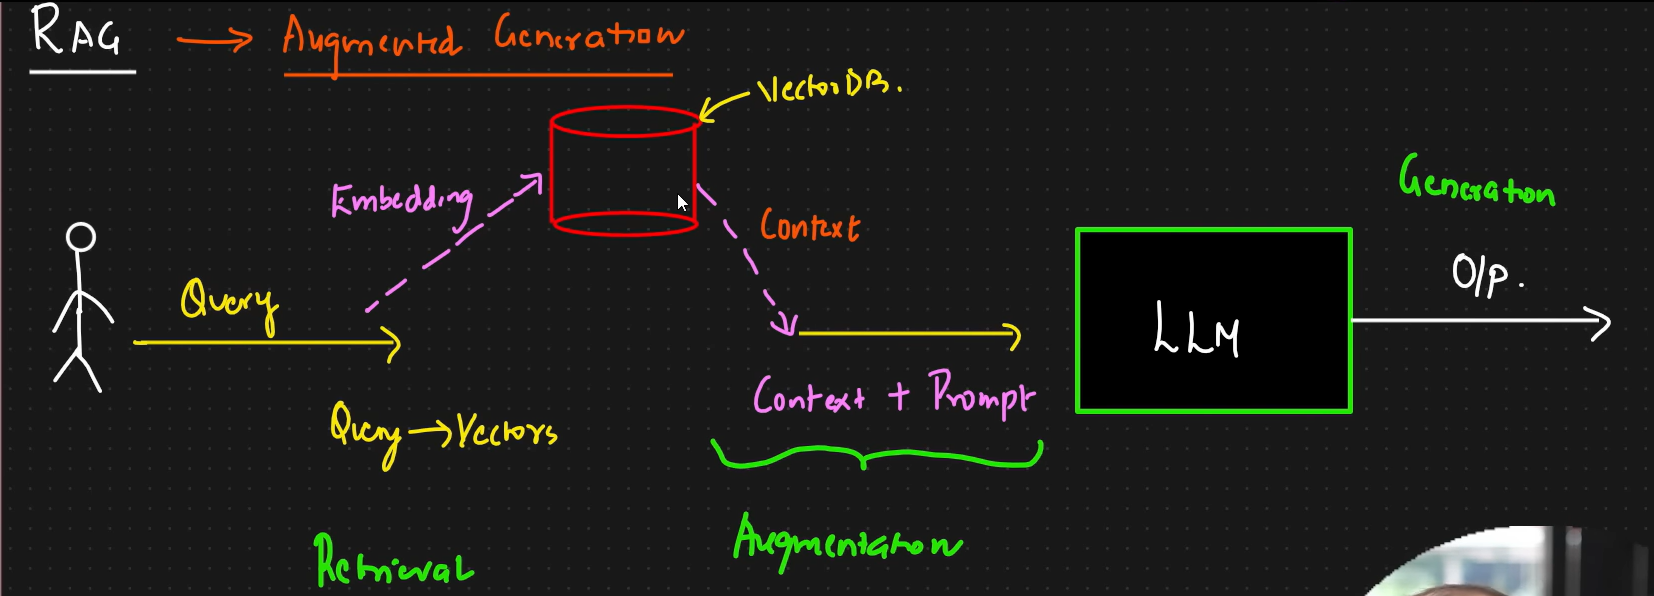

## RAG Pipeline- VectorDB To LLM Output Generation

In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()

print(os.getenv("GROQ_API_KEY"))

In [ ]:
from langchain_groq import ChatGroq
from langchain.prompts import PromptTemplate
from langchain.schema import HumanMessage, SystemMessage

In [ ]:
class GroqLLM:
    def __init__(self, model_name: str = "gemma2-9b-it", api_key: str =None):
        """
        Initialize Groq LLM
        
        Args:
            model_name: Groq model name (qwen2-72b-instruct, llama3-70b-8192, etc.)
            api_key: Groq API key (or set GROQ_API_KEY environment variable)
        """
        self.model_name = model_name
        self.api_key = api_key or os.environ.get("GROQ_API_KEY")
        
        if not self.api_key:
            raise ValueError("Groq API key is required. Set GROQ_API_KEY environment variable or pass api_key parameter.")
        
        self.llm = ChatGroq(
            groq_api_key=self.api_key,
            model_name=self.model_name,
            temperature=0.1,
            max_tokens=1024
        )
        
        print(f"Initialized Groq LLM with model: {self.model_name}")

    def generate_response(self, query: str, context: str, max_length: int = 500) -> str:
        """
        Generate response using retrieved context
        
        Args:
            query: User question
            context: Retrieved document context
            max_length: Maximum response length
            
        Returns:
            Generated response string
        """
        
        # Create prompt template
        prompt_template = PromptTemplate(
            input_variables=["context", "question"],
            template="""You are a helpful AI assistant. Use the following context to answer the question accurately and concisely.

Context:
{context}

Question: {question}

Answer: Provide a clear and informative answer based on the context above. If the context doesn't contain enough information to answer the question, say so."""
        )
        
        # Format the prompt
        formatted_prompt = prompt_template.format(context=context, question=query)
        
        try:
            # Generate response
            messages = [HumanMessage(content=formatted_prompt)]
            response = self.llm.invoke(messages)
            return response.content
            
        except Exception as e:
            return f"Error generating response: {str(e)}"
        
    def generate_response_simple(self, query: str, context: str) -> str:
        """
        Simple response generation without complex prompting
        
        Args:
            query: User question
            context: Retrieved context
            
        Returns:
            Generated response
        """
        simple_prompt = f"""Based on this context: {context}

Question: {query}

Answer:"""
        
        try:
            messages = [HumanMessage(content=simple_prompt)]
            response = self.llm.invoke(messages)
            return response.content
        except Exception as e:
            return f"Error: {str(e)}"
    

In [ ]:
# Initialize Groq LLM (you'll need to set GROQ_API_KEY environment variable)
try:
    groq_llm = GroqLLM(api_key=os.getenv("GROQ_API_KEY"))
    print("Groq LLM initialized successfully!")
except ValueError as e:
    print(f"Warning: {e}")
    print("Please set your GROQ_API_KEY environment variable to use the LLM.")
    groq_llm = None

In [ ]:
### get the context from the retriever and pass it to the LLM

rag_retriever.retrieve("Unified Multi-task Learning Framework")

## Integration Vectordb Context pipeline With LLM output

In [14]:
import os
from dotenv import load_dotenv          ## to load entire environment variables 
load_dotenv()

print(os.getenv("GROQ_API_KEY"))


### Initialize the Grok LLM (set your GROQ_API_KEY in environment)

groq_api_key=os.getenv("GROQ_API_KEY")

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


We persisted in the local directory so that we can always read whenever we definitely want based on a specific query. 

In [15]:
### Simple RAG pipeline with Groq LLM
from langchain_groq import ChatGroq
import os
from dotenv import load_dotenv
load_dotenv()

### Initialize the Groq LLM (set your GROQ_API_KEY in environment)
groq_api_key = os.getenv("GROQ_API_KEY")

llm=ChatGroq(groq_api_key=groq_api_key,model_name="llama-3.3-70b-versatile",temperature=0.1,max_tokens=1024)

## 2. Simple RAG function: retrieve context + generate response
def rag_simple(query,retriever,llm,top_k=3):
    ## retriever the context
    results=retriever.retrieve(query,top_k=top_k)
    context="\n\n".join([doc['content'] for doc in results]) if results else ""
    if not context:
        return "No relevant context found to answer the question."
    
    ## generate the answwer using GROQ LLM
    prompt=f"""Use the following context to answer the question concisely.
        Context:
        {context}

        Question: {query}

        Answer:"""
    
    response=llm.invoke([prompt.format(context=context,query=query)])
    return response.content

In [16]:
answer=rag_simple("What is attention mechanism?",rag_retriever,llm)
print(answer)

Retrieving documents for query: 'What is attention mechanism?'
Top K: 3, Score threshold: 0.0
Generating embeddings for 1 texts...


Batches: 100%|██████████| 1/1 [00:00<00:00, 48.80it/s]

Generated embeddings with shape: (1, 384)
Retrieved 3 documents (after filtering)


An attention mechanism is a function that maps a query and key-value pairs to an output, computing it as a weighted sum of the values, where all inputs and outputs are vectors.


In [17]:
# answer=rag_simple("What is Google LLC?",rag_retriever,llm)
# print(answer)

## Enhanced RAG Pipeline Features

In [20]:
# --- Enhanced RAG Pipeline Features ---
def rag_advanced(query, retriever, llm, top_k=5, min_score=0.2, return_context=False):
    """
    RAG pipeline with extra features:
    - Returns answer, sources, confidence score, and optionally full context.
    """
    results = retriever.retrieve(query, top_k=top_k, score_threshold=min_score)
    if not results:
        return {'answer': 'No relevant context found.', 'sources': [], 'confidence': 0.0, 'context': ''}
    
    # Prepare context and sources
    context = "\n\n".join([doc['content'] for doc in results])
    sources = [{
        'source': doc['metadata'].get('source_file', doc['metadata'].get('source', 'unknown')),
        'page': doc['metadata'].get('page', 'unknown'),
        'score': doc['similarity_score'],
        'preview': doc['content'][:300] + '...'
    } for doc in results]
    confidence = max([doc['similarity_score'] for doc in results])
    
    # Generate answer
    prompt = f"""Use the following context to answer the question concisely.\nContext:\n{context}\n\nQuestion: {query}\n\nAnswer:"""
    response = llm.invoke([prompt.format(context=context, query=query)])
    
    output = {
        'answer': response.content,
        'sources': sources,
        'confidence': confidence
    }
    if return_context:
        output['context'] = context
    return output

# Example usage:
result = rag_advanced("What is Embeddings", rag_retriever, llm, top_k=3, min_score=0.1, return_context=True)
print("Answer:", result['answer'])
print("Sources:", result['sources'])
print("Confidence:", result['confidence'])
print("Context Preview:", result['context'][:300])

Retrieving documents for query: 'What is Embeddings'
Top K: 3, Score threshold: 0.1
Generating embeddings for 1 texts...


Batches: 100%|██████████| 1/1 [00:00<00:00, 43.20it/s]

Generated embeddings with shape: (1, 384)
Retrieved 3 documents (after filtering)


Answer: Embeddings refer to the numerical representation of objects, such as words or images, in a vector form, where similar objects have similar vector representations.
Sources: [{'source': '1610.08229v1.pdf', 'page': 6, 'score': 0.23934060335159302, 'preview': 'Word Embeddings for Sentence Classiﬁcation Tasks• July 2016\nand learn to make them based on appearance,\nrotation, 3D pose, and various object attributes.\nAnother difference is that while word em-\nbeddings are usually low-ranked, image em-\nbeddings might have same or even higher di-\nmension then the ...'}, {'source': '1610.08229v1.pdf', 'page': 0, 'score': 0.2114015817642212, 'preview': 'I. I ntroduction\nT\nhere are some deﬁnitions for what Word\nEmbeddings are, but in the most general\nnotion, word embeddings are the numer-\nical representation of words, usually in a shape\nof a vector in ℜd. Being more speciﬁc, word\nembeddings are unsupervisedly learned word\nrepresentation vectors whos...'}, {'source': '1610.08229v1

In [21]:
# --- Advanced RAG Pipeline: Streaming, Citations, History, Summarization ---
from typing import List, Dict, Any
import time

class AdvancedRAGPipeline:
    def __init__(self, retriever, llm):
        self.retriever = retriever
        self.llm = llm
        self.history = []  # Store query history

    def query(self, question: str, top_k: int = 5, min_score: float = 0.2, stream: bool = False, summarize: bool = False) -> Dict[str, Any]:
        # Retrieve relevant documents
        results = self.retriever.retrieve(question, top_k=top_k, score_threshold=min_score)
        if not results:
            answer = "No relevant context found."
            sources = []
            context = ""
        else:
            context = "\n\n".join([doc['content'] for doc in results])
            sources = [{
                'source': doc['metadata'].get('source_file', doc['metadata'].get('source', 'unknown')),
                'page': doc['metadata'].get('page', 'unknown'),
                'score': doc['similarity_score'],
                'preview': doc['content'][:120] + '...'
            } for doc in results]
            # Streaming answer simulation
            prompt = f"""Use the following context to answer the question concisely.\nContext:\n{context}\n\nQuestion: {question}\n\nAnswer:"""
            if stream:
                print("Streaming answer:")
                for i in range(0, len(prompt), 80):
                    print(prompt[i:i+80], end='', flush=True)
                    time.sleep(0.05)
                print()
            response = self.llm.invoke([prompt.format(context=context, question=question)])
            answer = response.content

        # Add citations to answer
        citations = [f"[{i+1}] {src['source']} (page {src['page']})" for i, src in enumerate(sources)]
        answer_with_citations = answer + "\n\nCitations:\n" + "\n".join(citations) if citations else answer

        # Optionally summarize answer
        summary = None
        if summarize and answer:
            summary_prompt = f"Summarize the following answer in 2 sentences:\n{answer}"
            summary_resp = self.llm.invoke([summary_prompt])
            summary = summary_resp.content

        # Store query history
        self.history.append({
            'question': question,
            'answer': answer,
            'sources': sources,
            'summary': summary
        })

        return {
            'question': question,
            'answer': answer_with_citations,
            'sources': sources,
            'summary': summary,
            'history': self.history
        }

# Example usage:
adv_rag = AdvancedRAGPipeline(rag_retriever, llm)
result = adv_rag.query("what is attention is all you need", top_k=3, min_score=0.1, stream=True, summarize=True)
print("\nFinal Answer:", result['answer'])
print("Summary:", result['summary'])
print("History:", result['history'][-1])

Retrieving documents for query: 'what is attention is all you need'
Top K: 3, Score threshold: 0.1
Generating embeddings for 1 texts...


Batches: 100%|██████████| 1/1 [00:00<00:00, 23.04it/s]

Generated embeddings with shape: (1, 384)
Retrieved 3 documents (after filtering)
Streaming answer:
Use the following context to answer the question concisely.
Context:
3.2 Attention
An attention function can be described as mapping a query and a set of key-value pairs to an output,
where the query, keys, values, and output are all vectors. The output is computed as a weighted sum
3

3.2 Attention
An attention functi

on can be described as mapping a query and a set of key-value pairs to an output,
where the query, keys, values, and output are all vectors. The output is computed as a weighted sum
3

3.2 Attention
An attention function can be described as mapping a query and a set of key-value pairs to an output,
where the query, keys, values, and output are all vectors. The output is computed as a weighted sum
3

Question: what is attention is all you need

Answer:

Final Answer: "Attention is All You Need" refers to a paper that introduced the Transformer model, which relies entirely on attention mechanisms to process input sequences, eliminating the need for recurrent neural networks (RNNs) and convolutional neural networks (CNNs).

Citations:
[1] attention-is-all-you-need.pdf (page 2)
[2] attention-is-all-you-need.pdf (page 2)
[3] attention-is-all-you-need.pdf (page 2)
Summary: The paper "Attention is All You Need" introduced the Transformer model, a novel approach to processing input sequences. 